<a href="https://colab.research.google.com/github/santhoshjothi540/weather_prediction/blob/main/AIML_CT_PROJECT1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

WEATHER PREDICTION PROJECT

# **Abstract**

This project focuses on developing a weather prediction system using machine learning techniques to accurately classify weather conditions based on historical weather data. The Seattle Weather dataset is used, which contains features such as precipitation, maximum temperature, minimum temperature, and wind speed. The project follows a complete machine learning pipeline that includes data preprocessing, exploratory data analysis (EDA), feature engineering, outlier removal, label encoding, feature scaling, model training, and performance evaluation. A Random Forest Classifier is used to build the prediction model due to its high accuracy and robustness. The model is evaluated using metrics such as accuracy score, confusion matrix, and classification report, and is saved using Joblib for future predictions without retraining. This project demonstrates how machine learning can effectively analyze weather patterns and provide reliable weather forecasts, making it useful for applications in agriculture, transportation, disaster management, and daily planning.



---


# Readme File


---


# Seattle Weather Analysis and Prediction

## Project Title
Seattle Weather Analysis and Prediction using Machine Learning

## Description
This project analyzes the Seattle Weather dataset using Python. It includes data preprocessing, Exploratory Data Analysis (EDA), data visualization, outlier detection using IQR, classification algorithms, and regression algorithms to analyze and predict weather conditions.

---

## Dataset
Dataset Name: Seattle Weather Dataset

File Name:
```
seattle-weather.csv
```

---

## Technologies Used

- Python 3.12
- Google Colab
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn

---

## System Requirements

### Operating System
- Windows 10 / Windows 11

### Python Version
```
Python 3.12
```

### Platform
```
Google Colab
```

### Browser
- Google Chrome

---

## Required Libraries

```python
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
```

---

## Performance Metrics

### Classification
- Accuracy Score
- Confusion Matrix
- Classification Report

### Regression
- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)

---

## Author

Name: Santhosh J

Department:
B.E. Computer Science and Engineering

Academic Year:
2026

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving seattle-weather.csv to seattle-weather (1).csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

READ DATASET

In [ ]:
df = pd.read_csv("seattle-weather.csv")

DISPLAY FIRST FIVE ROWS

In [ ]:
df.head()

,date,precipitation,temp_max,temp_min,wind,weather
0,2012-01-01,0.0,12.8,5.0,4.7,drizzle
1,2012-01-02,10.9,10.6,2.8,4.5,rain
2,2012-01-03,0.8,11.7,7.2,2.3,rain
3,2012-01-04,20.3,12.2,5.6,4.7,rain
4,2012-01-05,1.3,8.9,2.8,6.1,rain


DISPLAY LAST FIVE ROWS

In [ ]:
df.tail()

,date,precipitation,temp_max,temp_min,wind,weather
1456,2015-12-27,8.6,4.4,1.7,2.9,rain
1457,2015-12-28,1.5,5.0,1.7,1.3,rain
1458,2015-12-29,0.0,7.2,0.6,2.6,fog
1459,2015-12-30,0.0,5.6,-1.0,3.4,sun
1460,2015-12-31,0.0,5.6,-2.1,3.5,sun


SHAPE OF DATASET

In [ ]:
df.shape

(1461, 6)

COLUMN NAMES

In [ ]:
df.columns

Index(['date', 'precipitation', 'temp_max', 'temp_min', 'wind', 'weather'], dtype='object')

DATA TYPES

In [ ]:
df.dtypes

,0
date,object
precipitation,float64
temp_max,float64
temp_min,float64
wind,float64
weather,object


DATASET INFORMATION

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           1461 non-null   object 
 1   precipitation  1461 non-null   float64
 2   temp_max       1461 non-null   float64
 3   temp_min       1461 non-null   float64
 4   wind           1461 non-null   float64
 5   weather        1461 non-null   object 
dtypes: float64(4), object(2)
memory usage: 68.6+ KB


STATISTICAL SUMMARY

In [ ]:
df.describe()

,precipitation,temp_max,temp_min,wind
count,1461.000000,1461.000000,1461.000000,1461.000000
mean,3.029432,16.439083,8.234771,3.241136
std,6.680194,7.349758,5.023004,1.437825
min,0.000000,-1.600000,-7.100000,0.400000
25%,0.000000,10.600000,4.400000,2.200000
50%,0.000000,15.600000,8.300000,3.000000
75%,2.800000,22.200000,12.200000,4.000000
max,55.900000,35.600000,18.300000,9.500000


MISSING VALUES

In [ ]:
df.isnull().sum()

,0
date,0
precipitation,0
temp_max,0
temp_min,0
wind,0
weather,0


DUPLICATE VALUES

In [ ]:
df.duplicated().sum()

np.int64(0)

REMOVE DUPLICATE VALUES

In [ ]:
df = df.drop_duplicates()

PERFORM EDA

In [ ]:
#weather distribution
df["weather"].value_counts()

,count
weather,
rain,641
sun,640
fog,101
drizzle,53
snow,26


In [ ]:
#Percentage of Weather Types
df["weather"].value_counts(normalize=True) * 100

,proportion
weather,
rain,43.874059
sun,43.805613
fog,6.913073
drizzle,3.627652
snow,1.779603


In [ ]:
# Mean
df.mean(numeric_only=True)

,0
precipitation,3.029432
temp_max,16.439083
temp_min,8.234771
wind,3.241136


In [ ]:
#Median
df.median(numeric_only=True)

,0
precipitation,0.0
temp_max,15.6
temp_min,8.3
wind,3.0


In [ ]:
# Maximum Values
df.max(numeric_only=True)

,0
precipitation,55.9
temp_max,35.6
temp_min,18.3
wind,9.5


In [ ]:
# Minimum Values
df.min(numeric_only=True)

,0
precipitation,0.0
temp_max,-1.6
temp_min,-7.1
wind,0.4


In [ ]:
# Standard Deviation
df.std(numeric_only=True)

,0
precipitation,6.680194
temp_max,7.349758
temp_min,5.023004
wind,1.437825


In [ ]:
# Correlation Matrix
df.corr(numeric_only=True)

,precipitation,temp_max,temp_min,wind
precipitation,1.000000,-0.228555,-0.072684,0.328045
temp_max,-0.228555,1.000000,0.875687,-0.164857
temp_min,-0.072684,0.875687,1.000000,-0.074185
wind,0.328045,-0.164857,-0.074185,1.000000


STEP 3 : FEATURE RELATIONSHIP ANALYSIS

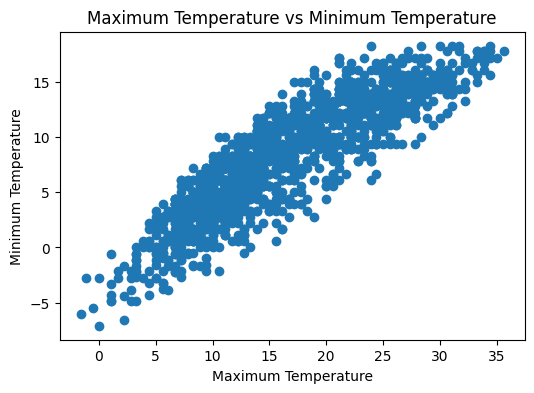

In [ ]:
# Temperature Max vs Temperature Min
plt.figure(figsize=(6,4))
plt.scatter(df["temp_max"],df["temp_min"])
plt.xlabel("Maximum Temperature")
plt.ylabel("Minimum Temperature")
plt.title("Maximum Temperature vs Minimum Temperature")
plt.show()

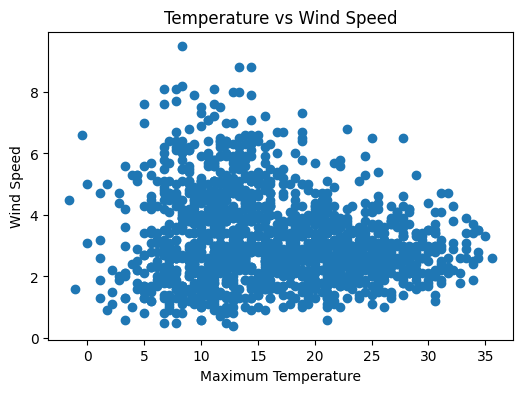

In [ ]:
# Temperature vs Wind
plt.figure(figsize=(6,4))
plt.scatter(df["temp_max"],df["wind"])
plt.xlabel("Maximum Temperature")
plt.ylabel("Wind Speed")
plt.title("Temperature vs Wind Speed")
plt.show()

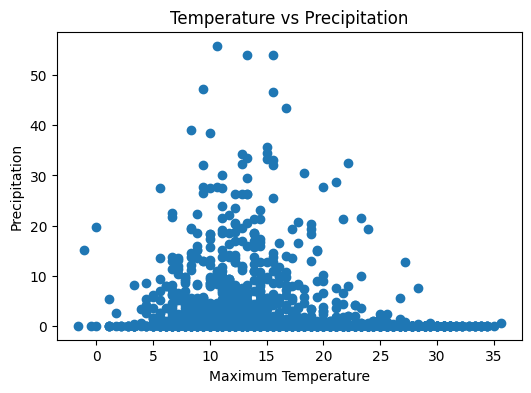

In [ ]:
# Temperature vs Precipitation
plt.figure(figsize=(6,4))
plt.scatter(df["temp_max"],df["precipitation"])
plt.xlabel("Maximum Temperature")
plt.ylabel("Precipitation")
plt.title("Temperature vs Precipitation")
plt.show()

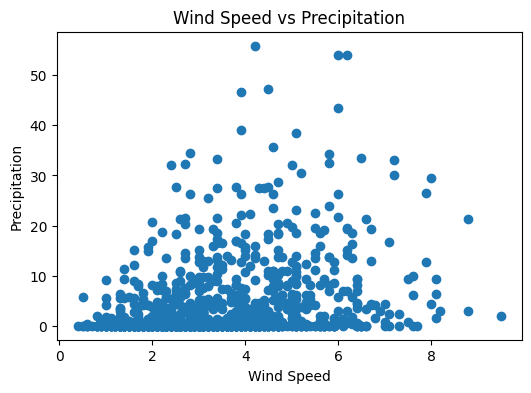

In [ ]:
# Wind vs Precipitation
plt.figure(figsize=(6,4))
plt.scatter(df["wind"],df["precipitation"])
plt.xlabel("Wind Speed")
plt.ylabel("Precipitation")
plt.title("Wind Speed vs Precipitation")
plt.show()

STEP 4 : REMOVE OUTLIERS

In [ ]:
# Remove Outliers Using IQR Method
Q1 = df["temp_max"].quantile(0.25)

Q3 = df["temp_max"].quantile(0.75)

IQR = Q3 - Q1

Lower = Q1 - 1.5 * IQR

Upper = Q3 + 1.5 * IQR

df = df[(df["temp_max"] >= Lower) & (df["temp_max"] <= Upper)]

In [ ]:
# Check Shape After Removing Outliers
df.shape

(1461, 6)

Boxplot After Removing Outliers

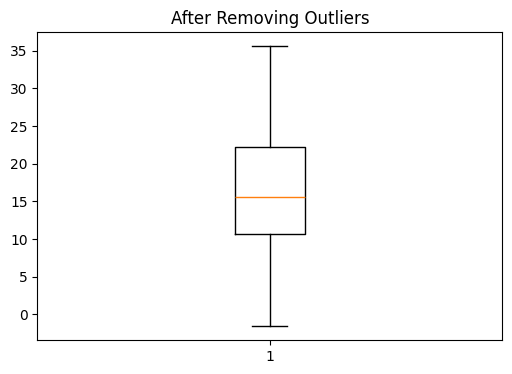

In [ ]:
plt.figure(figsize=(6,4))
plt.boxplot(df["temp_max"])
plt.title("After Removing Outliers")
plt.show()

STEP 5 : DATA VISUALIZATION

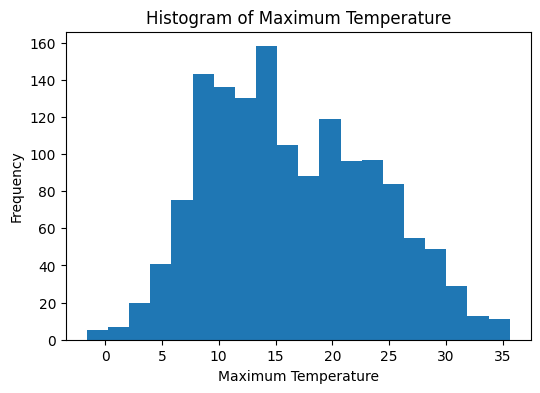

In [ ]:
# Histogram
plt.figure(figsize=(6,4))
plt.hist(df["temp_max"],bins=20)
plt.xlabel("Maximum Temperature")
plt.ylabel("Frequency")
plt.title("Histogram of Maximum Temperature")
plt.show()

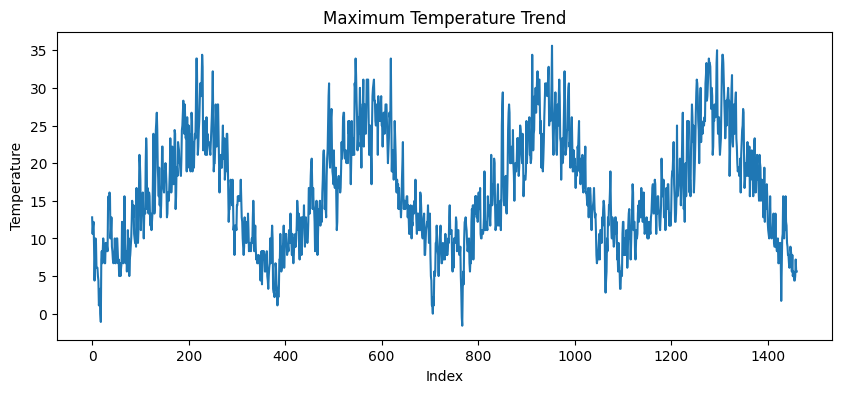

In [ ]:
# Line Plot
plt.figure(figsize=(10,4))
plt.plot(df["temp_max"])
plt.title("Maximum Temperature Trend")
plt.xlabel("Index")
plt.ylabel("Temperature")
plt.show()

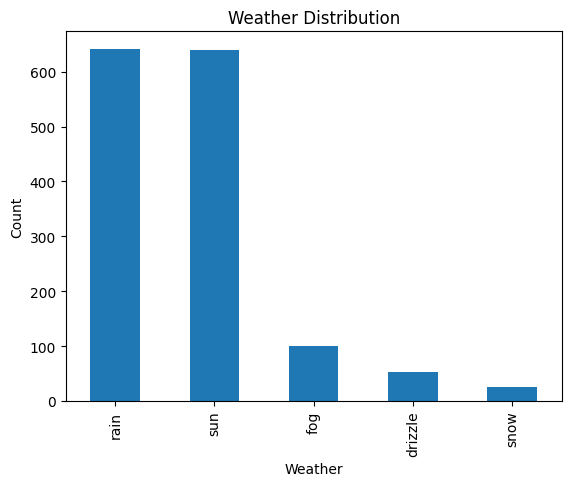

In [ ]:
# Bar Chart
df["weather"].value_counts().plot(kind="bar")
plt.xlabel("Weather")
plt.ylabel("Count")
plt.title("Weather Distribution")
plt.show()

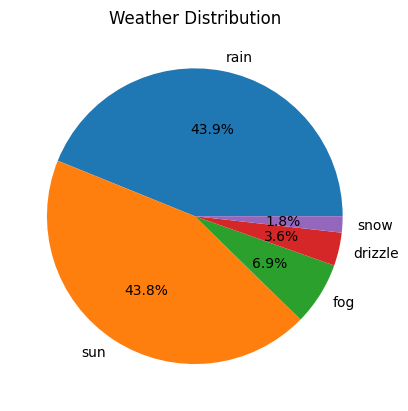

In [ ]:
# Pie Chart
df["weather"].value_counts().plot(kind="pie",autopct="%1.1f%%")
plt.title("Weather Distribution")
plt.ylabel("")
plt.show()

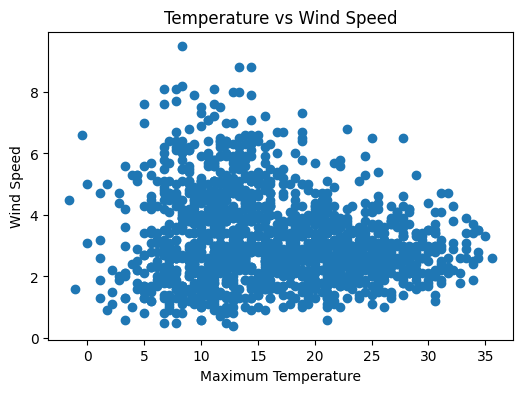

In [ ]:
# Scatter Plot
plt.figure(figsize=(6,4))
plt.scatter(df["temp_max"],df["wind"])
plt.xlabel("Maximum Temperature")
plt.ylabel("Wind Speed")
plt.title("Temperature vs Wind Speed")
plt.show()

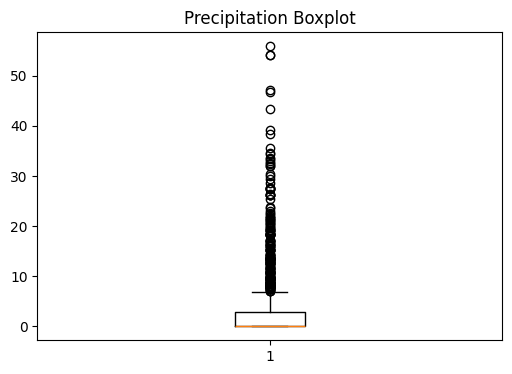

In [ ]:
# Box Plot
plt.figure(figsize=(6,4))
plt.boxplot(df["precipitation"])
plt.title("Precipitation Boxplot")
plt.show()

In [ ]:
# Save Clean Dataset
df.to_csv("clean_weather_dataset.csv", index=False)

In [ ]:
#STEP 1
import pandas as pd
import numpy as np
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# Load dataset
df = pd.read_csv("/content/seattle-weather.csv")

# Display first 5 rows
print(df.head())

         date  precipitation  temp_max  temp_min  wind  weather
0  2012-01-01            0.0      12.8       5.0   4.7  drizzle
1  2012-01-02           10.9      10.6       2.8   4.5     rain
2  2012-01-03            0.8      11.7       7.2   2.3     rain
3  2012-01-04           20.3      12.2       5.6   4.7     rain
4  2012-01-05            1.3       8.9       2.8   6.1     rain


In [ ]:
# Step 2: Load Dataset

import pandas as pd

# Read the CSV file
df = pd.read_csv("/content/seattle-weather.csv")

# Display the first 5 rows
print(df.head(5))

# Display the last 5 rows
print(df.tail(5))

         date  precipitation  temp_max  temp_min  wind  weather
0  2012-01-01            0.0      12.8       5.0   4.7  drizzle
1  2012-01-02           10.9      10.6       2.8   4.5     rain
2  2012-01-03            0.8      11.7       7.2   2.3     rain
3  2012-01-04           20.3      12.2       5.6   4.7     rain
4  2012-01-05            1.3       8.9       2.8   6.1     rain
            date  precipitation  temp_max  temp_min  wind weather
1456  2015-12-27            8.6       4.4       1.7   2.9    rain
1457  2015-12-28            1.5       5.0       1.7   1.3    rain
1458  2015-12-29            0.0       7.2       0.6   2.6     fog
1459  2015-12-30            0.0       5.6      -1.0   3.4     sun
1460  2015-12-31            0.0       5.6      -2.1   3.5     sun


In [ ]:
# Step 3: Understand Dataset

# Shape of the dataset
print("Shape of the dataset:")
print(df.shape)

# Column names
print("\nColumns:")
print(df.columns)

# Data types of each column
print("\nData Types:")
print(df.dtypes)

# Information about the dataset
print("\nDataset Information:")
df.info()

# Statistical summary
print("\nStatistical Summary:")
print(df.describe())

Shape of the dataset:
(1461, 6)

Columns:
Index(['date', 'precipitation', 'temp_max', 'temp_min', 'wind', 'weather'], dtype='object')

Data Types:
date              object
precipitation    float64
temp_max         float64
temp_min         float64
wind             float64
weather           object
dtype: object

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           1461 non-null   object 
 1   precipitation  1461 non-null   float64
 2   temp_max       1461 non-null   float64
 3   temp_min       1461 non-null   float64
 4   wind           1461 non-null   float64
 5   weather        1461 non-null   object 
dtypes: float64(4), object(2)
memory usage: 68.6+ KB

Statistical Summary:
       precipitation     temp_max     temp_min         wind
count    1461.000000  1461.000000  1461.000000  1461.000000
mean        3.

Missing Values:
date             0
precipitation    0
temp_max         0
temp_min         0
wind             0
weather          0
dtype: int64

Duplicate Values:
0

Correlation Matrix:
               precipitation  temp_max  temp_min      wind
precipitation       1.000000 -0.228555 -0.072684  0.328045
temp_max           -0.228555  1.000000  0.875687 -0.164857
temp_min           -0.072684  0.875687  1.000000 -0.074185
wind                0.328045 -0.164857 -0.074185  1.000000


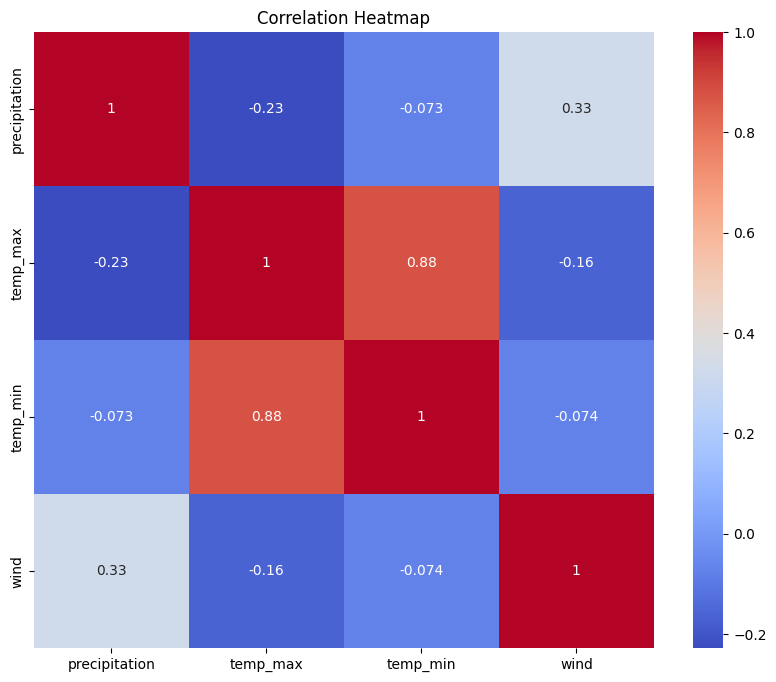

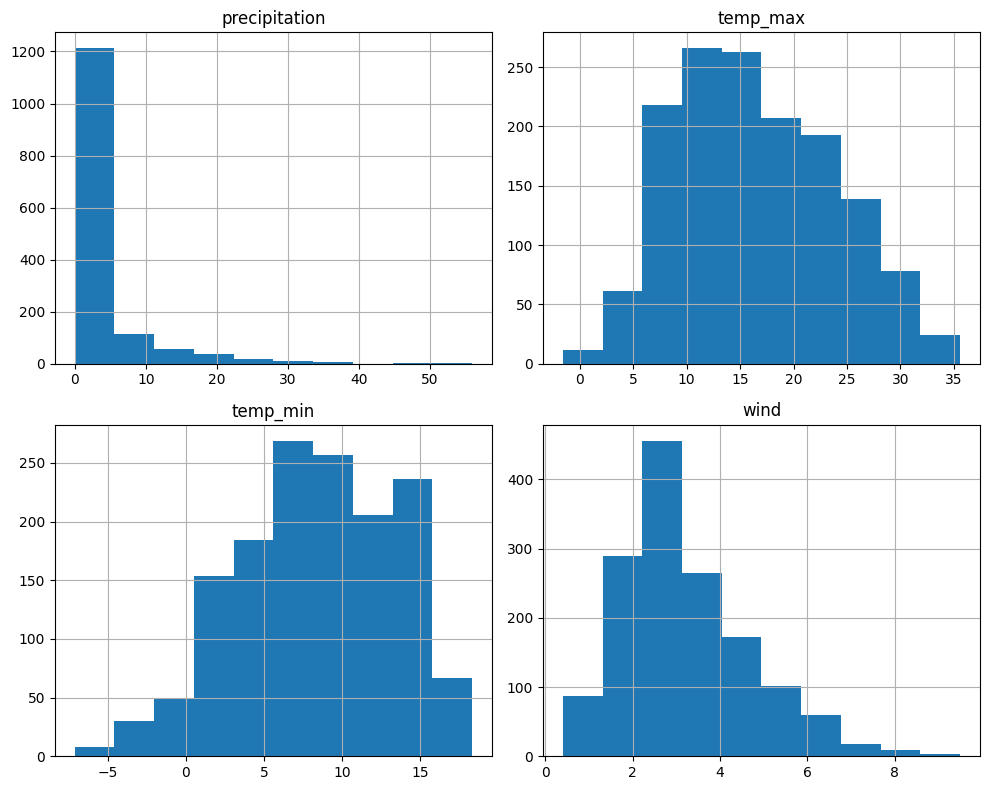

In [ ]:
# Step 4: Exploratory Data Analysis (EDA)

import matplotlib.pyplot as plt

# Check Missing Values
print("Missing Values:")
print(df.isnull().sum())

# Check Duplicate Values
print("\nDuplicate Values:")
print(df.duplicated().sum())

# Correlation Matrix
print("\nCorrelation Matrix:")
print(df.corr(numeric_only=True))

# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Histogram
df.hist(figsize=(10, 8))
plt.tight_layout()
plt.show()

In [ ]:
# Step 5: Data Cleaning

# Remove missing values
df.dropna(inplace=True)

# Fill missing values (for numeric columns)
df.fillna(df.mean(numeric_only=True), inplace=True)

# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Remove outliers using the IQR method on 'temp_max'

Q1 = df["temp_max"].quantile(0.25)
Q3 = df["temp_max"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df["temp_max"] >= lower) & (df["temp_max"] <= upper)]

# Display the cleaned dataset
print(df.head())

# Check the new shape
print("Dataset Shape:", df.shape)

         date  precipitation  temp_max  temp_min  wind  weather
0  2012-01-01            0.0      12.8       5.0   4.7  drizzle
1  2012-01-02           10.9      10.6       2.8   4.5     rain
2  2012-01-03            0.8      11.7       7.2   2.3     rain
3  2012-01-04           20.3      12.2       5.6   4.7     rain
4  2012-01-05            1.3       8.9       2.8   6.1     rain
Dataset Shape: (1461, 6)


In [ ]:
# Step 6: Feature Engineering

# Create a new feature: Temperature Range
df["temp_range"] = df["temp_max"] - df["temp_min"]

# Display the first 5 rows
print(df.head())

         date  precipitation  temp_max  temp_min  wind  weather  temp_range
0  2012-01-01            0.0      12.8       5.0   4.7  drizzle         7.8
1  2012-01-02           10.9      10.6       2.8   4.5     rain         7.8
2  2012-01-03            0.8      11.7       7.2   2.3     rain         4.5
3  2012-01-04           20.3      12.2       5.6   4.7     rain         6.6
4  2012-01-05            1.3       8.9       2.8   6.1     rain         6.1


In [ ]:
# Step 7: Feature Selection

# Independent Variables (Features)
X = df[["precipitation", "temp_max", "temp_min", "wind"]]

# Dependent Variable (Target)
y = df["weather"]

# Display the features and target
print("Independent Variables (X):")
print(X.head())

print("\nDependent Variable (y):")
print(y.head())

Independent Variables (X):
   precipitation  temp_max  temp_min  wind
0            0.0      12.8       5.0   4.7
1           10.9      10.6       2.8   4.5
2            0.8      11.7       7.2   2.3
3           20.3      12.2       5.6   4.7
4            1.3       8.9       2.8   6.1

Dependent Variable (y):
0    drizzle
1       rain
2       rain
3       rain
4       rain
Name: weather, dtype: object


In [ ]:
# Step 8: Encoding

from sklearn.preprocessing import LabelEncoder

# Create LabelEncoder object
le = LabelEncoder()

# Encode the target variable (weather)
y = le.fit_transform(y)

# Display the encoded values
print("Encoded Target Variable:")
print(y[:10])

# Display the class mapping
print("\nClass Labels:")
for i, label in enumerate(le.classes_):
    print(f"{label} = {i}")

Encoded Target Variable:
[0 2 2 2 2 2 2 4 2 2]

Class Labels:
drizzle = 0
fog = 1
rain = 2
snow = 3
sun = 4


In [ ]:
# Step 9: Feature Scaling

from sklearn.preprocessing import StandardScaler

# Create StandardScaler object
scaler = StandardScaler()

# Scale the independent variables
X = scaler.fit_transform(X)

# Display the scaled features
print(X[:5])

[[-0.45364986 -0.49529914 -0.64421175  1.01497975]
 [ 1.17859791 -0.79473121 -1.08234662  0.87583314]
 [-0.33385186 -0.64501518 -0.20607688 -0.65477956]
 [ 2.58622442 -0.57696243 -0.52472042  1.01497975]
 [-0.2589781  -1.02611054 -1.08234662  1.98900601]]


In [ ]:
# Step 10: Train-Test Split

from sklearn.model_selection import train_test_split

# Split the dataset into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Display the shape of the datasets
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (1168, 4)
X_test shape : (293, 4)
y_train shape: (1168,)
y_test shape : (293,)


In [ ]:
print(X_train)
print(y_train)

[[-0.45364986 -1.47525865 -2.27725991  1.71071279]
 [ 2.31667892 -0.3455831   0.35154932  2.12815262]
 [ 2.36160317 -0.57696243 -0.42514431 -0.72435286]
 ...
 [-0.37877611 -0.11420378 -0.20607688 -0.79392617]
 [-0.45364986 -1.47525865 -1.83912504  0.11052679]
 [-0.45364986 -1.25748987 -0.98277052 -0.93307278]]
[1 2 2 ... 2 4 1]


RANDOM FOREST ALGORITHM

In [ ]:
#STEP 11
from sklearn.ensemble import RandomForestClassifier

# Create the Random Forest model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [ ]:
# Step 12: Train the Model

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [ ]:
# Step 13: Prediction

# Predict the target values for the test dataset
y_pred = model.predict(X_test)

# Display the predicted values
print("Predicted Values:")
print(y_pred)

Predicted Values:
[4 2 2 0 2 2 4 4 2 4 4 4 2 4 4 2 4 2 4 4 2 4 2 4 4 2 4 4 4 4 2 4 4 3 4 2 2
 2 2 4 2 4 4 4 4 2 2 4 2 4 4 2 4 2 4 2 2 4 2 4 2 4 2 4 4 4 2 4 2 2 2 4 4 2
 2 4 2 4 2 2 2 4 2 4 2 4 4 2 4 2 2 4 4 2 2 4 4 2 4 2 4 4 2 3 2 4 4 2 4 2 2
 4 2 2 4 0 4 4 4 2 2 2 2 2 4 4 4 4 4 4 4 4 4 0 4 4 2 2 2 4 4 4 2 2 4 1 4 2
 4 4 2 4 4 4 2 3 1 4 2 2 1 4 2 4 1 2 2 4 4 4 2 2 4 4 2 2 4 4 0 2 4 4 4 2 2
 4 2 2 4 4 4 4 4 2 4 4 4 2 2 2 2 4 0 2 4 2 2 4 3 4 2 4 4 4 4 4 4 4 2 4 2 4
 4 4 4 2 4 2 4 3 4 2 4 4 2 4 4 4 4 4 2 2 4 2 4 4 4 4 2 2 2 2 2 4 4 4 2 4 2
 2 2 2 4 2 4 4 2 1 4 4 4 1 4 2 4 4 2 2 4 4 4 2 4 2 4 4 2 4 4 2 4 2 4]


In [ ]:
# Step 14: Accuracy

from sklearn.metrics import accuracy_score

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

# Display accuracy
print("Accuracy:", accuracy)

# Display accuracy as a percentage
print("Accuracy Percentage:", accuracy * 100, "%")

Accuracy: 0.8191126279863481
Accuracy Percentage: 81.91126279863481 %


In [ ]:
# Step 15: Confusion Matrix

from sklearn.metrics import confusion_matrix

# Create the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display the confusion matrix
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[  1   0   0   0   8]
 [  1   3   1   0  20]
 [  0   0 110   3   7]
 [  0   0   6   2   0]
 [  3   3   1   0 124]]


In [ ]:
# Step 16: Classification Report

from sklearn.metrics import classification_report

# Display the classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.20      0.11      0.14         9
           1       0.50      0.12      0.19        25
           2       0.93      0.92      0.92       120
           3       0.40      0.25      0.31         8
           4       0.78      0.95      0.86       131

    accuracy                           0.82       293
   macro avg       0.56      0.47      0.48       293
weighted avg       0.79      0.82      0.79       293



In [ ]:
 #Step 17: Predict New Weather
 import pandas as pd

# New data with column names
new_data = pd.DataFrame(
    [[2.5, 20.0, 10.0, 4.5]],
    columns=["precipitation", "temp_max", "temp_min", "wind"]
)

# Scale the new data
new_data_scaled = scaler.transform(new_data)

# Predict the weather
prediction = model.predict(new_data_scaled)

# Convert encoded prediction back to original label
predicted_weather = le.inverse_transform(prediction)

print("Predicted Weather:", predicted_weather[0])

Predicted Weather: rain


In [ ]:
# Step 18: Save the Model

import joblib

# Save the trained model
joblib.dump(model, "weather_prediction_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [ ]:
# Step 19: Load Saved Model

import joblib

# Load the saved model
model = joblib.load("weather_prediction_model.pkl")

print("Model loaded successfully!")

Model loaded successfully!
